**Licenciatura en Ciencia de Datos — Inteligencia Artificial y Aprendizaje Automático I**

| | |
|---|---|
| **Trabajo Práctico** | TP1 — Análisis Exploratorio e Ingeniería de Características |
| **Integrantes** | Andrisani, Facundo · Feser, Ignacio · Lauria, Francisco · Viccei, Tomás |
| **Dataset** | Producción de pozos de gas y petróleo — Secretaría de Energía (Cap. IV) |
| **Año** | 2026 |

---
# FASE A — Contextualización y Formulación de Preguntas

## A.1 Dominio del problema y origen de los datos

El presente proyecto se enmarca en el dominio de la **industria energética**, específicamente en el sector *Upstream* de Oil & Gas (exploración y producción de hidrocarburos). La gestión eficiente de los yacimientos requiere el monitoreo continuo de múltiples variables operativas, geológicas y mecánicas. Comprender el comportamiento de los fluidos (petróleo, gas, agua) y la respuesta de los pozos ante diferentes técnicas de estimulación es crucial para optimizar la rentabilidad, prevenir el agotamiento prematuro de las reservas y planificar el mantenimiento de la infraestructura.

Los datos provienen de los **registros oficiales de producción e inyección de la Secretaría de Energía de la Nación (Capítulo IV)**, que recopilan las declaraciones juradas mensuales presentadas por las operadoras del sector. El conjunto abarca información sobre el rendimiento mensual, el estado técnico, la ubicación geográfica y la configuración geológica de miles de perforaciones a nivel nacional.

**Dimensiones del dataset:** 992.698 registros × 38 variables. Cumple holgadamente el mínimo exigido (1.500 filas × 12 columnas) y presenta las imperfecciones reales requeridas: columnas con hasta el **94,56%** de valores nulos y outliers físicos severos (profundidades de hasta ~379.000 m).

## A.2 Diccionario de variables

Las 38 variables se agrupan según su rol analítico:

### Variables numéricas — Operativas y de rendimiento
| Variable | Descripción | Unidad |
|---|---|---|
| `prod_pet` | Producción mensual de petróleo | m³ |
| `prod_gas` | Producción mensual de gas natural | miles de m³ |
| `prod_agua` | Producción mensual de agua de formación | m³ |
| `iny_agua` | Volumen de agua inyectada (recuperación secundaria) | m³ |
| `iny_gas`, `iny_co2`, `iny_otro` | Volúmenes de inyección de gas, CO₂ y otros | m³ |
| `tef` | Tiempo efectivo de funcionamiento en el mes | días |
| `profundidad` | Profundidad total de la perforación | m |
| `vida_util` | Vida útil estimada del pozo | años |

### Variables categóricas — Estructurales y geográficas
| Variable | Descripción |
|---|---|
| `tipoestado` | Estado operativo o administrativo del pozo |
| `tipoextraccion` | Método de levantamiento de fluidos |
| `tipopozo` | Clasificación del pozo (petrolífero, gasífero, etc.) |
| `cuenca` | Cuenca sedimentaria del yacimiento |
| `provincia` | Jurisdicción territorial |
| `formacion`, `formprod` | Formación geológica productiva |
| `tipo_de_recurso` | Convencional / No convencional |
| `empresa`, `sigla` | Operadora del pozo |

### Variables de identificación y control
`idempresa`, `idpozo`, `idusuario`, `anio`, `mes`, `fechaingreso`, `fecha_data`, `rectificado`, `habilitado`, y códigos de área/concesión. Se utilizan para trazabilidad, no como predictores.

## A.3 Formulación de las 10 preguntas de interés

Las preguntas se organizan según la fase del proyecto integrador que alimentan.

### Preguntas analíticas / descriptivas (EDA — este TP1)

**P1. Frecuencia operativa:** ¿Cuál es la proporción de pozos inactivos o abandonados frente a los que reportan extracción efectiva continua?

**P2. Distribución de rendimiento:** Excluyendo los pozos inactivos, ¿cómo se distribuye estadísticamente `prod_pet` y qué grado de asimetría presenta el parque productivo nacional?

**P3. Anomalías de medición:** ¿Existen registros con valores atípicos severos o físicamente imposibles en `tef` o `profundidad` que requieran limpieza por reglas de dominio?

**P4. Relaciones operativas:** ¿Existe una correlación directa y monótona entre el volumen de agua extraída (`prod_agua`) y la producción de petróleo?

**P5. Impacto geográfico:** ¿Qué cuencas registran los volúmenes de producción promedio más altos y cómo se distribuye la actividad a nivel provincial?

**P6. Sistemas de levantamiento:** ¿Cuánto influye el método de extracción (`tipoextraccion`) en los niveles máximos de producción?

### Preguntas de predicción / regresión (→ TP2)

**P7. Estimación de producción:** ¿Es posible predecir el volumen de petróleo (`prod_pet`) de un pozo activo a partir de sus características operativas, técnicas y geográficas?

**P8. Variables determinantes:** ¿Cuáles son las variables con mayor poder predictivo sobre la producción de petróleo?

### Preguntas de clasificación (→ TP3)

**P9. Clasificación de estado operativo:** ¿Es posible predecir si un pozo se encuentra **Activo** (extracción efectiva) o **Inactivo** (abandonado, parado, en estudio, etc.) a partir de sus variables descriptivas?

**P10. Impacto del desbalance:** Dado que la clase "Activo" es minoritaria (~31,65% de los registros en el dataset completo), ¿cómo afecta este **desbalance de clases** al desempeño de los clasificadores, y qué técnicas (ajuste de métricas, *oversampling* / SMOTE) permiten mitigarlo?

> **Nota de encadenamiento:** las preguntas P9 y P10 definen la variable objetivo del TP3 (`estado_binario`, derivada de `tipoestado`). El desbalance en el dataset completo es de **31,65% Activo / 68,35% Inactivo**; tras la limpieza por reglas de dominio (que elimina ~120 mil registros administrativos/no perforados, predominantemente inactivos) el target final del TP3 queda en **33,89% / 66,11% (ratio 1,95 : 1)**. Ambos valores anticipan la necesidad de técnicas de balanceo en la etapa de clasificación.

---
# FASE B — Análisis Exploratorio e Ingeniería de Características

## B.1 Carga de datos y análisis univariado

In [20]:
# ── Librerías ─────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

# ── Carga del dataset ─────────────────────────────────────────────────────────
df = pd.read_csv('produccin-de-pozos-de-gas-y-petrleo-2025 (1).csv', low_memory=False)

print(f'Dimensiones del dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas')
df.info()

Dimensiones del dataset: 992,698 filas × 38 columnas
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 992698 entries, 0 to 992697
Data columns (total 38 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   idempresa               992698 non-null  object 
 1   anio                    992698 non-null  int64  
 2   mes                     992698 non-null  int64  
 3   idpozo                  992698 non-null  int64  
 4   prod_pet                992698 non-null  float64
 5   prod_gas                992698 non-null  float64
 6   prod_agua               992698 non-null  float64
 7   iny_agua                992698 non-null  float64
 8   iny_gas                 992698 non-null  float64
 9   iny_co2                 992698 non-null  float64
 10  iny_otro                992698 non-null  float64
 11  tef                     992698 non-null  float64
 12  vida_util               72149 non-null   float64
 13  tipoextraccion       

In [21]:
# ── Resumen estadístico de las variables numéricas operativas ─────────────────
variables_operativas = ['prod_pet', 'prod_gas', 'prod_agua', 'iny_agua', 'tef', 'profundidad']

print('Resumen estadístico de las variables operativas (datos crudos):')
display(df[variables_operativas].describe(percentiles=[.25, .50, .75, .95, .99]).round(2))

Resumen estadístico de las variables operativas (datos crudos):


,prod_pet,prod_gas,prod_agua,iny_agua,tef,profundidad
count,992698.00,992698.00,992698.00,992698.00,992698.00,992698.00
mean,46.82,51.93,334.20,336.97,10.08,1704.87
std,311.12,880.03,1148.56,1995.70,13.94,1737.20
min,-0.08,-12.14,-12.11,0.00,-23.00,0.00
25%,0.00,0.00,0.00,0.00,0.00,1050.00
50%,0.00,0.00,0.00,0.00,0.00,1600.00
75%,6.54,0.00,10.78,0.00,29.19,2350.00
95%,133.88,68.92,2203.40,1992.88,31.00,3400.00
99%,939.26,980.69,5875.28,8443.01,31.00,5862.00
max,26593.26,133520.00,37771.49,218837.80,60.00,378939.00


Proporción detallada de pozos según estado operativo:
tipoestado
Extracción Efectiva                   31.65 %
Abandonado                            23.15 %
En Reserva para Recup. Sec./Asist.    10.48 %
En Estudio                             9.93 %
En Inyección Efectiva                  7.28 %
Parado Transitoriamente                6.37 %
A Abandonar                            3.21 %
En Espera de Reparación                2.27 %
Abandono Temporario                    1.68 %
Otras Situación Inactivo               1.56 %
Parado Alta Relación Agua/Petróleo     1.29 %
En Reserva de Gas                      0.66 %
Otras Situación Activo                 0.25 %
Parado Alta Relación Gas/Petróleo      0.13 %
En Reparación                          0.05 %
Mantenimiento de Presión               0.04 %


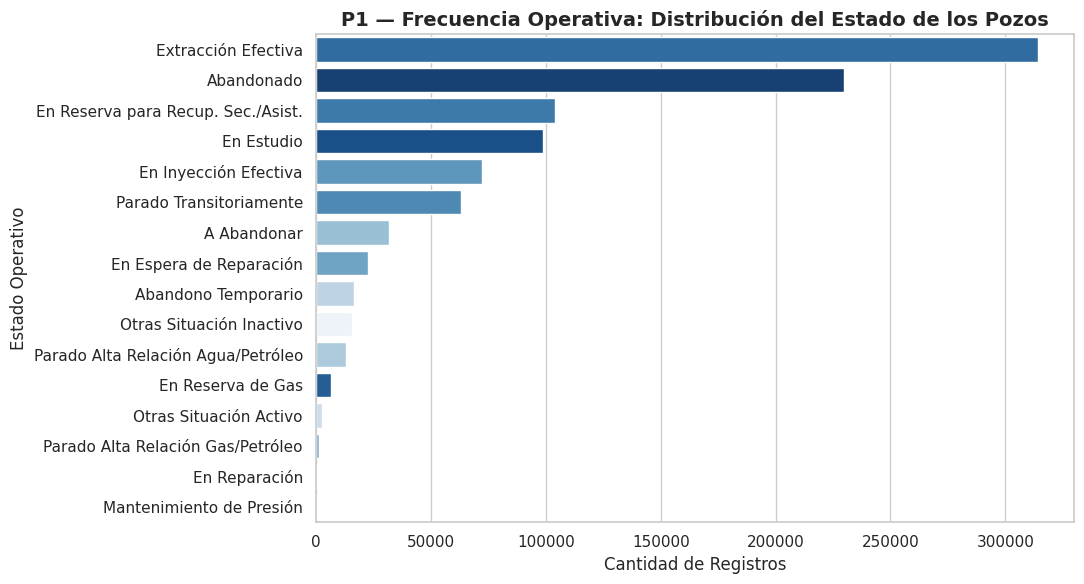

In [22]:
# ── P1: Distribución del estado operativo de los pozos ────────────────────────
# Población: dataset COMPLETO (necesitamos todos los estados para ver el desbalance real)
distribucion_estado = df['tipoestado'].value_counts(normalize=True) * 100
print('Proporción detallada de pozos según estado operativo:')
print((distribucion_estado.round(2).astype(str) + ' %').to_string())

plt.figure(figsize=(11, 6))
sns.countplot(y=df['tipoestado'], order=df['tipoestado'].value_counts().index,
              hue=df['tipoestado'], palette='Blues_r', legend=False)
plt.title('P1 — Frecuencia Operativa: Distribución del Estado de los Pozos',
          fontsize=14, weight='bold')
plt.xlabel('Cantidad de Registros'); plt.ylabel('Estado Operativo')
plt.tight_layout(); plt.show()

> **Respuesta P1:** Solo el **31,65%** de los registros corresponde a pozos en Extracción Efectiva; el **68,35%** restante agrupa estados de inactividad, reserva o procesos alternativos. Aproximadamente 2 de cada 3 registros no representan producción declarada como efectiva. Este desbalance ~32/68 será la base de la variable objetivo del TP3 y anticipa la necesidad de técnicas de balanceo de clases.
>
> **Aclaración — dos definiciones de "activo" (no equivalentes):** el estado declarado *Extracción Efectiva* (31,65%) **no coincide exactamente** con tener producción de petróleo positiva `prod_pet > 0` (28,47%). La brecha se explica principalmente por **pozos gasíferos** en extracción efectiva (`prod_pet = 0` pero `prod_gas > 0`) y por rezagos administrativos. En consecuencia, en este TP las preguntas de distribución productiva (P2–P6) usan la definición operativa `prod_pet > 0`, mientras que la variable objetivo del TP3 (P9–P10) usa el **estado declarado** `tipoestado`.

Pozos con prod_pet > 0:                  282,648 (28.47%)
Pozos con estado "Extracción Efectiva":  314,212 (31.65%)
Brecha (gasíferos en EE + rezagos):      31,564 registros


Resumen estadístico de prod_pet en pozos activos (m³/mes):


,count,mean,std,min,25%,50%,75%,95%,99%,max
prod_pet,282648.0,164.44,566.23,0.0,18.04,42.01,94.18,608.06,2801.55,26593.26



Media:    164.44 m³/mes
Mediana:  42.01 m³/mes
Razón media/mediana: 3.91  (>1 indica asimetría positiva)
Coeficiente de asimetría (skewness): 9.02


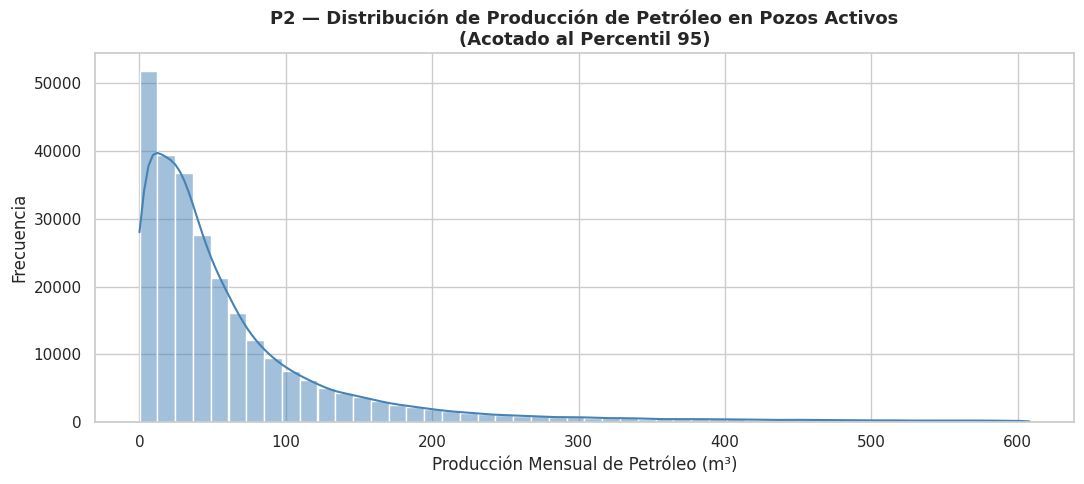

In [23]:
# ── P2: Distribución de prod_pet en pozos ACTIVOS ─────────────────────────────
# Población: solo pozos activos (prod_pet > 0) para evitar la inflación de ceros
# que destruiría la varianza y sesgaría el análisis de la distribución productiva.
df_activos = df[df['prod_pet'] > 0].copy()

# Aclaración: "activo" tiene dos acepciones en este análisis y NO coinciden exactamente:
#   (a) producción real:   prod_pet > 0                          (población de P2–P6)
#   (b) estado declarado:  tipoestado == 'Extracción Efectiva'   (target del TP3, P9–P10)
n_prod   = (df['prod_pet'] > 0).sum()
n_estado = (df['tipoestado'] == 'Extracción Efectiva').sum()
print(f'Pozos con prod_pet > 0:                  {n_prod:,} ({n_prod/len(df)*100:.2f}%)')
print(f'Pozos con estado "Extracción Efectiva":  {n_estado:,} ({n_estado/len(df)*100:.2f}%)')
print(f'Brecha (gasíferos en EE + rezagos):      {n_estado - n_prod:,} registros\n')

print('\nResumen estadístico de prod_pet en pozos activos (m³/mes):')
display(df_activos['prod_pet'].describe(percentiles=[.25, .50, .75, .95, .99]).round(2).to_frame().T)

# Cuantificación de la asimetría
media = df_activos['prod_pet'].mean()
mediana = df_activos['prod_pet'].median()
skew = df_activos['prod_pet'].skew()
print(f'\nMedia:    {media:.2f} m³/mes')
print(f'Mediana:  {mediana:.2f} m³/mes')
print(f'Razón media/mediana: {media/mediana:.2f}  (>1 indica asimetría positiva)')
print(f'Coeficiente de asimetría (skewness): {skew:.2f}')

# Histograma acotado al P95 para visualizar la forma central
p95 = df_activos['prod_pet'].quantile(0.95)
plt.figure(figsize=(11, 5))
sns.histplot(df_activos[df_activos['prod_pet'] <= p95]['prod_pet'],
             bins=50, kde=True, color='steelblue')
plt.title('P2 — Distribución de Producción de Petróleo en Pozos Activos\n(Acotado al Percentil 95)',
          fontsize=13, weight='bold')
plt.xlabel('Producción Mensual de Petróleo (m³)'); plt.ylabel('Frecuencia')
plt.tight_layout(); plt.show()

> **Respuesta P2:** La distribución es **fuertemente asimétrica a derecha**. La media (164 m³/mes) casi cuadruplica a la mediana (42 m³/mes), y el coeficiente de asimetría supera holgadamente el umbral de asimetría severa. El parque productivo responde a una lógica tipo Pareto: la mayoría de los pozos produce volúmenes modestos mientras un grupo reducido de alta productividad tracciona el promedio. Esto obligará a transformaciones logarítmicas o modelos robustos en el TP2.

Auditoría de calidad de datos (reglas de dominio) sobre datos crudos:
- Registros con tef negativo:                  5
- Registros con tef > 31 días:                 11
- Registros con profundidad > 10.000 m:        84
- Profundidad máxima observada:                378,939 m


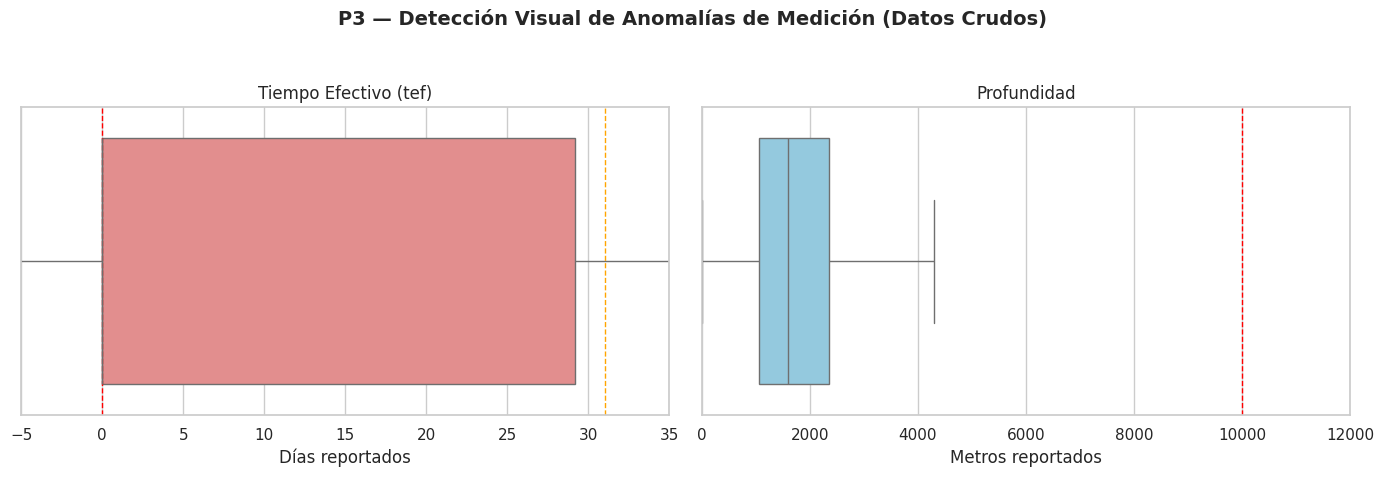

In [24]:
# ── P3: Auditoría de anomalías de medición (reglas de dominio) ────────────────
print('Auditoría de calidad de datos (reglas de dominio) sobre datos crudos:')
print(f'- Registros con tef negativo:                  {len(df[df["tef"] < 0]):,}')
print(f'- Registros con tef > 31 días:                 {len(df[df["tef"] > 31]):,}')
print(f'- Registros con profundidad > 10.000 m:        {len(df[df["profundidad"] > 10000]):,}')
print(f'- Profundidad máxima observada:                {df["profundidad"].max():,.0f} m')

# Visualización de outliers acotada a rangos físicamente válidos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('P3 — Detección Visual de Anomalías de Medición (Datos Crudos)',
             fontsize=14, weight='bold')

sns.boxplot(x=df['tef'], ax=axes[0], color='lightcoral', showfliers=False)
axes[0].set_title('Tiempo Efectivo (tef)'); axes[0].set_xlabel('Días reportados')
axes[0].set_xlim(-5, 35)
axes[0].axvline(0, color='red', ls='--', lw=1); axes[0].axvline(31, color='orange', ls='--', lw=1)

sns.boxplot(x=df['profundidad'], ax=axes[1], color='skyblue', showfliers=False)
axes[1].set_title('Profundidad'); axes[1].set_xlabel('Metros reportados')
axes[1].set_xlim(0, 12000)
axes[1].axvline(10000, color='red', ls='--', lw=1)

plt.tight_layout(rect=[0, 0.03, 1, 0.94]); plt.show()

> **Respuesta P3:** Sí. Se detectan registros con `tef` negativo (imposible físicamente), `tef` > 31 días (imposible en un mes calendario) y `profundidad` inverosímil, incluyendo un caso extremo cercano a los **379.000 m** — más de 30 veces la profundidad del pozo más profundo del mundo (Kola SG-3, ~12.262 m). Estas anomalías se corrigen en la Fase B.3 mediante reglas de dominio: `tef` con valor absoluto y tope en 31, `profundidad` acotada a 10.000 m.

## B.2 Análisis bivariado

El análisis bivariado examina las relaciones entre pares de variables, fundamentando las respuestas a las preguntas P4, P5 y P6, y sentando las bases para la selección de features de los TP2 y TP3.

Correlación de Spearman de cada variable con prod_pet (target TP2):
prod_agua      0.444
profundidad    0.198
prod_gas       0.128
tef            0.119
iny_agua      -0.027


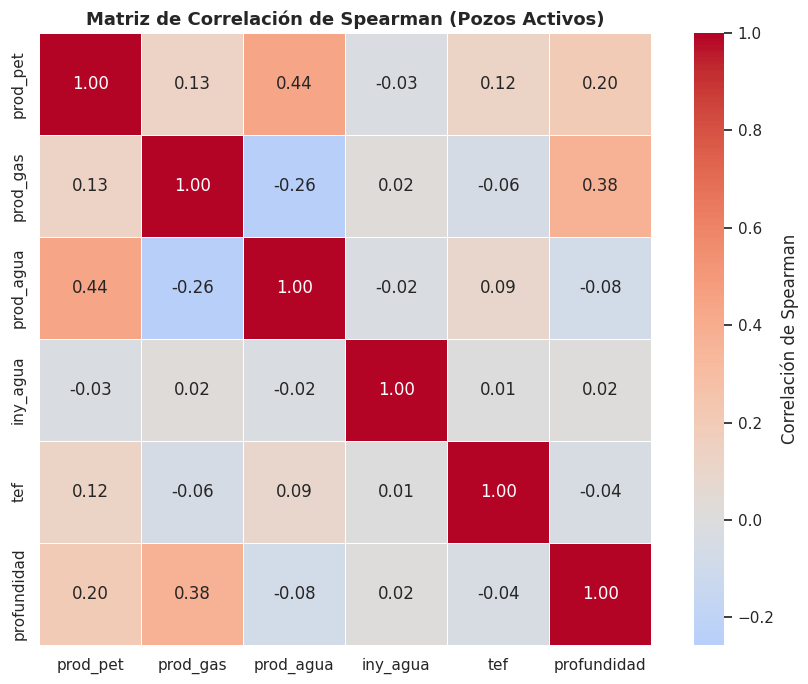

In [25]:
# ── Matriz de correlación de Spearman (robusta ante asimetría) ────────────────
# Se usa Spearman en lugar de Pearson porque todas las variables presentan
# distribuciones fuertemente asimétricas (demostrado en P2).
vars_corr = ['prod_pet', 'prod_gas', 'prod_agua', 'iny_agua', 'tef', 'profundidad']
corr = df_activos[vars_corr].corr(method='spearman')

# Correlación explícita de cada variable con el target de regresión (prod_pet).
# Sustenta numéricamente la selección de features de C.2.
corr_target = corr['prod_pet'].drop('prod_pet').sort_values(ascending=False)
print('Correlación de Spearman de cada variable con prod_pet (target TP2):')
print(corr_target.round(3).to_string())

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=.5, cbar_kws={'label': 'Correlación de Spearman'})
plt.title('Matriz de Correlación de Spearman (Pozos Activos)', fontsize=13, weight='bold')
plt.tight_layout(); plt.show()

P4 — Coeficiente de Spearman (prod_agua vs prod_pet): 0.44


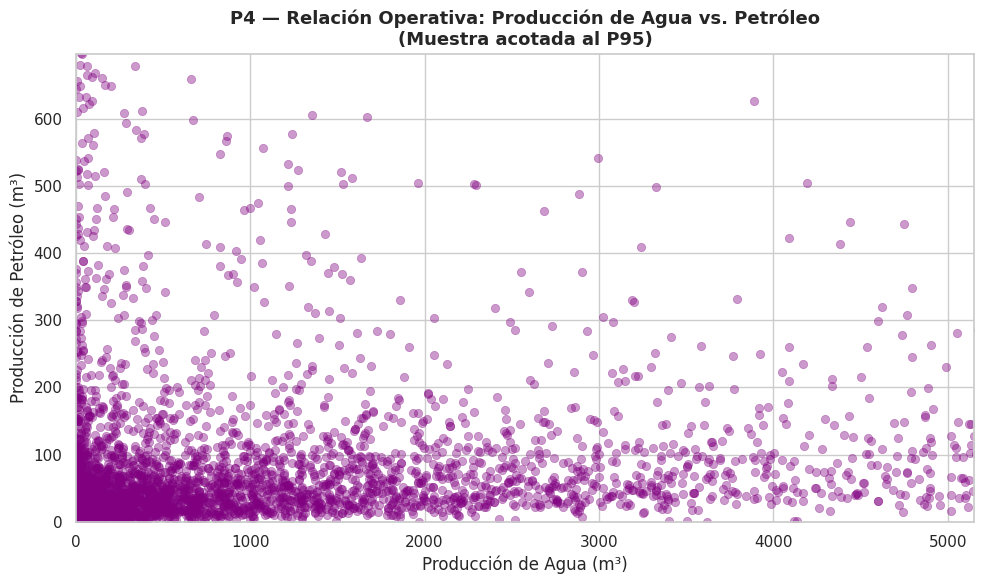

In [26]:
# ── P4: Relación prod_agua vs prod_pet ────────────────────────────────────────
rho = df_activos[['prod_agua', 'prod_pet']].corr(method='spearman').iloc[0, 1]
print(f'P4 — Coeficiente de Spearman (prod_agua vs prod_pet): {rho:.2f}')

n = min(5000, len(df_activos))
muestra = df_activos.sample(n=n, random_state=42)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=muestra, x='prod_agua', y='prod_pet', alpha=0.4, color='purple', edgecolor=None)
plt.title('P4 — Relación Operativa: Producción de Agua vs. Petróleo\n(Muestra acotada al P95)',
          fontsize=13, weight='bold')
plt.xlabel('Producción de Agua (m³)'); plt.ylabel('Producción de Petróleo (m³)')
plt.xlim(0, muestra['prod_agua'].quantile(0.95)); plt.ylim(0, muestra['prod_pet'].quantile(0.95))
plt.tight_layout(); plt.show()

> **Respuesta P4:** La correlación de Spearman es **ρ = 0,44**, una asociación **positiva moderada**. Refleja la resultante de dos efectos: el *efecto capacidad* (pozos más productivos generan más fluido total, tanto petróleo como agua) empuja la correlación al alza, mientras que el *efecto water cut* (pozos maduros aumentan su corte de agua mientras declina el petróleo) genera la dispersión y el techo decreciente visible en el scatter. `prod_agua` aporta señal predictiva moderada, útil para el TP2.

P5.1 — Producción promedio de petróleo por cuenca (m³/mes):


,Promedio prod_pet
cuenca,
NEUQUINA,310.27
NOROESTE,204.42
AUSTRAL,88.94
CUYANA,87.31
GOLFO SAN JORGE,68.76


P5.2 — Producción total acumulada por provincia (m³/mes):


,Total prod_pet
provincia,
Neuquén,30036657.20
Chubut,7233024.67
Santa Cruz,3592333.05
Mendoza,3099064.61
Rio Negro,1231603.20
La Pampa,660932.38
Estado Nacional,263744.93
Tierra del Fuego,189805.57
Salta,130863.61


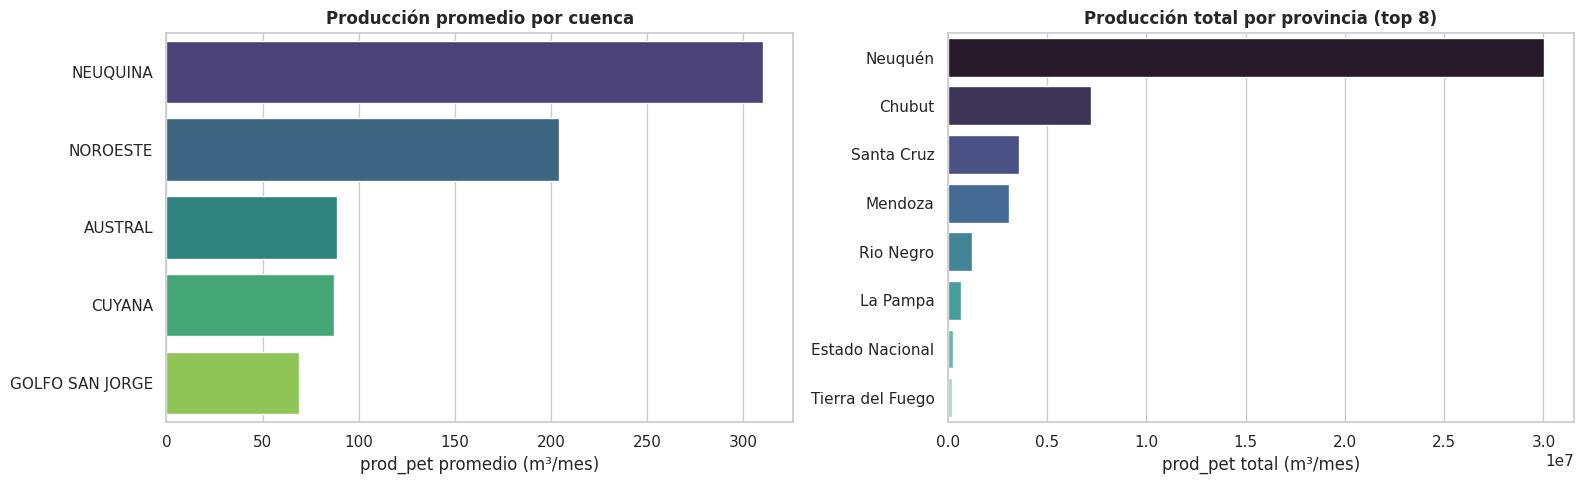

In [27]:
# ── P5: Producción por cuenca y provincia ─────────────────────────────────────
print('P5.1 — Producción promedio de petróleo por cuenca (m³/mes):')
prod_cuenca = df_activos.groupby('cuenca')['prod_pet'].mean().sort_values(ascending=False)
display(prod_cuenca.round(2).to_frame('Promedio prod_pet'))

print('P5.2 — Producción total acumulada por provincia (m³/mes):')
prod_prov = df_activos.groupby('provincia')['prod_pet'].sum().sort_values(ascending=False)
display(prod_prov.round(2).to_frame('Total prod_pet'))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(x=prod_cuenca.values, y=prod_cuenca.index, hue=prod_cuenca.index,
            palette='viridis', legend=False, ax=axes[0])
axes[0].set_title('Producción promedio por cuenca', fontsize=12, weight='bold')
axes[0].set_xlabel('prod_pet promedio (m³/mes)'); axes[0].set_ylabel('')

top_prov = prod_prov.head(8)
sns.barplot(x=top_prov.values, y=top_prov.index, hue=top_prov.index,
            palette='mako', legend=False, ax=axes[1])
axes[1].set_title('Producción total por provincia (top 8)', fontsize=12, weight='bold')
axes[1].set_xlabel('prod_pet total (m³/mes)'); axes[1].set_ylabel('')

plt.tight_layout(); plt.show()

> **Respuesta P5:** La **Cuenca Neuquina** lidera en producción promedio (310 m³/mes), más que cuadruplicando al Golfo San Jorge (69 m³/mes), gracias al desarrollo no convencional de Vaca Muerta. A nivel provincial, **Neuquén concentra ~64,7% de la producción total nacional**, y las cuatro primeras provincias acumulan ~94,6%. La estructura productiva presenta una doble concentración: por cuenca (Neuquina) y por provincia (Neuquén).

P6 — Rendimiento según sistema de levantamiento (m³/mes):


,Mediana,Promedio,Maximo,Cantidad
tipoextraccion,,,,
Surgencia Natural,32.86,640.36,26593.26,36907
Electrosumergible,72.10,106.29,5326.26,40721
Bombeo Mecánico,35.57,73.25,3994.64,146274
Cavidad Progresiva,65.94,108.21,2015.89,39988
Plunger Lift,15.19,25.12,706.29,7488
Pistoneo (Swabbing),1.34,2.58,59.54,6258


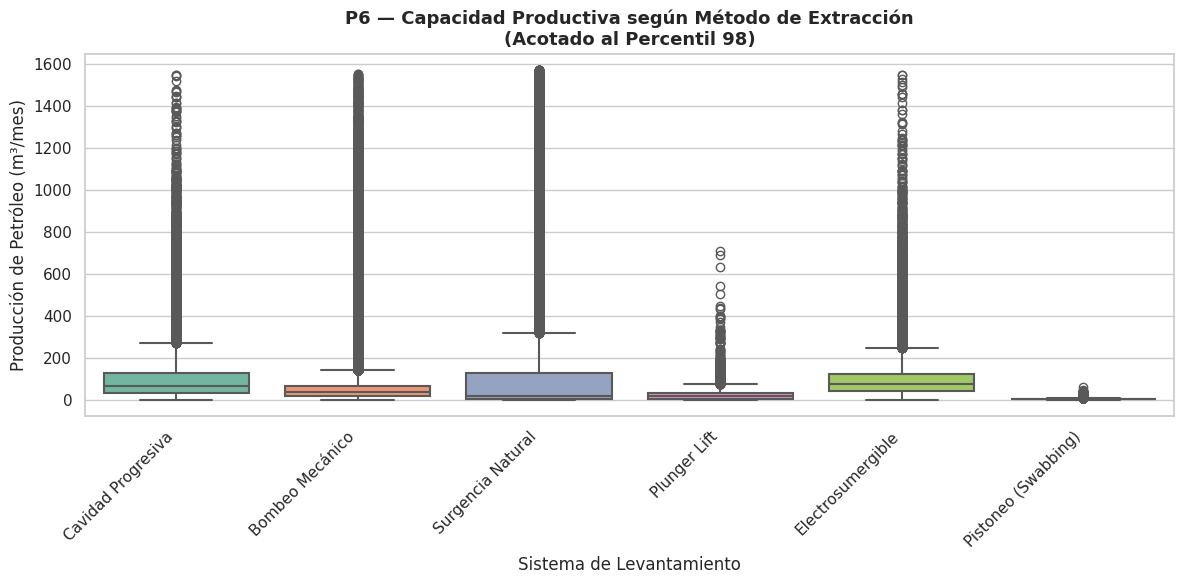

In [28]:
# ── P6: Influencia del método de extracción sobre la producción ───────────────
top_metodos = df_activos['tipoextraccion'].value_counts().nlargest(6).index
df_metodos = df_activos[df_activos['tipoextraccion'].isin(top_metodos)]

resumen = df_metodos.groupby('tipoextraccion')['prod_pet'].agg(
    Mediana='median', Promedio='mean', Maximo='max', Cantidad='count'
).sort_values('Maximo', ascending=False)
print('P6 — Rendimiento según sistema de levantamiento (m³/mes):')
display(resumen.round(2))

p98 = df_metodos['prod_pet'].quantile(0.98)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_metodos[df_metodos['prod_pet'] <= p98], x='tipoextraccion', y='prod_pet',
            hue='tipoextraccion', palette='Set2', legend=False, linewidth=1.5)
plt.title('P6 — Capacidad Productiva según Método de Extracción\n(Acotado al Percentil 98)',
          fontsize=13, weight='bold')
plt.xlabel('Sistema de Levantamiento'); plt.ylabel('Producción de Petróleo (m³/mes)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

> **Respuesta P6:** El método influye **determinantemente** en el techo productivo. La **Surgencia Natural** registra el máximo absoluto (26.593 m³/mes) con una disociación media/mediana de ~19x, señal de dos poblaciones superpuestas: pozos convencionales maduros y pozos no convencionales de Vaca Muerta. El **Bombeo Mecánico** domina en volumen de uso (53% de los seis métodos principales) con rendimientos moderados, mientras el **Pistoneo** registra los valores más bajos (método de intervención, no de producción continua). `tipoextraccion` tendrá alto poder discriminante en TP2 y TP3.

Distribución de la variable objetivo del TP3 (estado binario, dataset completo):
tipoestado
Inactivo    68.35 %
Activo      31.65 %
Name: proportion, dtype: object


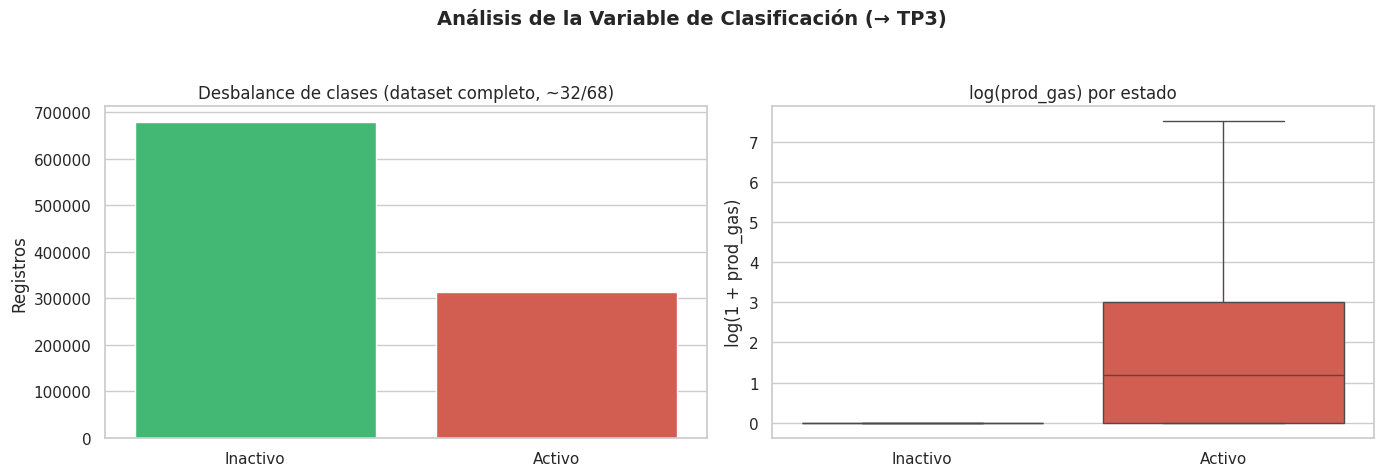

In [29]:
# ── Análisis bivariado de la variable de CLASIFICACIÓN (→ TP3) ─────────────────
# Construcción preliminar del estado binario sobre el dataset completo
estado_bin = df['tipoestado'].apply(
    lambda x: 'Activo' if x == 'Extracción Efectiva' else 'Inactivo'
)
print('Distribución de la variable objetivo del TP3 (estado binario, dataset completo):')
print((estado_bin.value_counts(normalize=True) * 100).round(2).astype(str) + ' %')

# Relación entre estado y producción de fluidos (log para visualización)
df_viz = df.copy()
df_viz['estado_bin'] = estado_bin
# clip(lower=0): prod_gas tiene negativos residuales (min -12,14) que romperían log1p.
df_viz['log_prod_gas'] = np.log1p(df_viz['prod_gas'].clip(lower=0))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Análisis de la Variable de Clasificación (→ TP3)', fontsize=14, weight='bold')

sns.countplot(x=estado_bin, hue=estado_bin, palette=['#2ecc71', '#e74c3c'],
              legend=False, ax=axes[0])
axes[0].set_title('Desbalance de clases (dataset completo, ~32/68)')
axes[0].set_xlabel(''); axes[0].set_ylabel('Registros')

sns.boxplot(data=df_viz, x='estado_bin', y='log_prod_gas', hue='estado_bin',
            palette=['#2ecc71', '#e74c3c'], legend=False, ax=axes[1], showfliers=False)
axes[1].set_title('log(prod_gas) por estado'); axes[1].set_xlabel(''); axes[1].set_ylabel('log(1 + prod_gas)')

plt.tight_layout(rect=[0, 0.03, 1, 0.94]); plt.show()

> **Análisis de clasificación:** En el dataset completo la variable objetivo del TP3 presenta un desbalance de **31,65% Activo / 68,35% Inactivo**. Tras la limpieza por reglas de dominio (Fase B.3, que elimina ~120 mil registros mayormente inactivos), el **target real del TP3 queda en 33,89% / 66,11% (ratio 1,95 : 1)**. Este desbalance es estructural del dominio (el parque acumula décadas de pozos abandonados) y tendrá impacto directo en las métricas: un clasificador ingenuo que prediga siempre "Inactivo" alcanzaría **66% de accuracy** sobre el conjunto ya limpio sin aprender nada útil. Por ello, en el TP3 se priorizarán métricas robustas al desbalance (F1-Score, Recall por clase, matriz de confusión) y se evaluará el uso de **SMOTE u otras técnicas de balanceo**.

## B.3 Tratamiento de valores faltantes

El diagnóstico de nulos revela **tres patrones diferenciados** que exigen tratamientos distintos, según la proporción de datos ausentes y la naturaleza de cada variable.

Variables con valores faltantes:


,Nulos,Porcentaje
sub_tipo_recurso,938684,94.56
vida_util,920549,92.73
observaciones,863004,86.94
clasificacion,202447,20.39
subclasificacion,202447,20.39
formacion,35801,3.61
formprod,34466,3.47
tipoestado,33,0.00
tipoextraccion,33,0.00
tipopozo,33,0.00


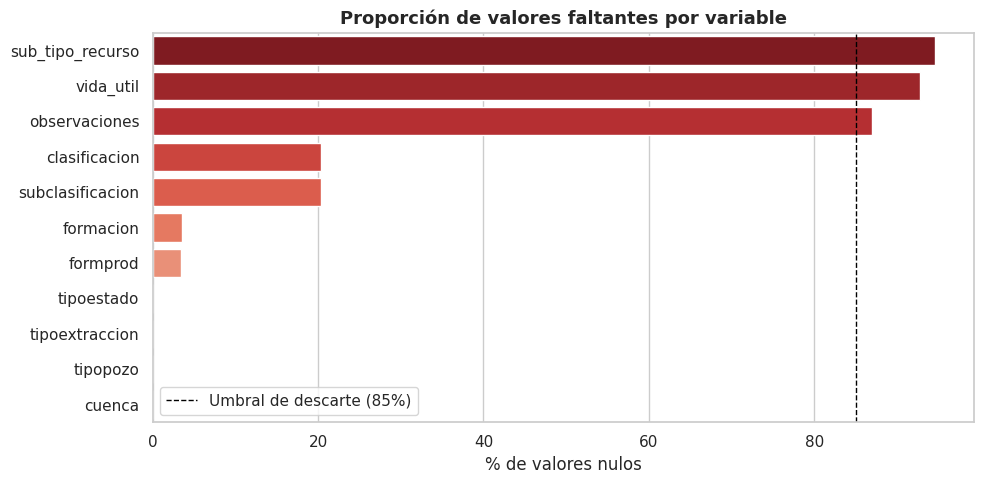

In [30]:
# ── Diagnóstico completo de valores faltantes ─────────────────────────────────
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df) * 100).round(2)
tabla_nulos = pd.DataFrame({'Nulos': nulos, 'Porcentaje': pct_nulos})
tabla_nulos = tabla_nulos[tabla_nulos['Nulos'] > 0].sort_values('Porcentaje', ascending=False)

print('Variables con valores faltantes:')
display(tabla_nulos)

plt.figure(figsize=(10, 5))
sns.barplot(x=tabla_nulos['Porcentaje'], y=tabla_nulos.index,
            hue=tabla_nulos.index, palette='Reds_r', legend=False)
plt.axvline(85, color='black', ls='--', lw=1, label='Umbral de descarte (85%)')
plt.title('Proporción de valores faltantes por variable', fontsize=13, weight='bold')
plt.xlabel('% de valores nulos'); plt.ylabel(''); plt.legend()
plt.tight_layout(); plt.show()

In [31]:
# ── Estrategia de tratamiento diferenciado de valores faltantes ───────────────
df_limpio = df.copy()

# CRITERIO 1 — Descarte de columnas con exceso de nulos (>85%): inservibles como features.
#   sub_tipo_recurso (94,56%), vida_util (92,73%), observaciones (86,94% + texto libre).
cols_descartar = ['vida_util', 'sub_tipo_recurso', 'observaciones']
df_limpio = df_limpio.drop(columns=cols_descartar)
print(f'CRITERIO 1 — Columnas descartadas por exceso de nulos (>85%): {cols_descartar}')

# CRITERIO 2 — Eliminación de las filas sin estado operativo.
#   'tipoestado' es la base de la variable objetivo del TP3: el target NO se imputa.
#   Estas mismas filas concentran los nulos de tipoextraccion y tipopozo.
antes = len(df_limpio)
df_limpio = df_limpio.dropna(subset=['tipoestado', 'tipoextraccion', 'tipopozo'])
print(f'CRITERIO 2 — Filas eliminadas sin estado/tipo (target no imputable): {antes - len(df_limpio):,}')

# CRITERIO 3 — Imputación por moda en categóricas con nulos leves (<5%).
#   Se incluye 'cuenca' porque forma parte del dataset exportado y debe quedar sin nulos.
cols_moda = ['formprod', 'formacion', 'cuenca']
for col in cols_moda:
    if col in df_limpio.columns:
        n_imp = df_limpio[col].isnull().sum()
        if n_imp > 0:
            moda = df_limpio[col].mode()[0]
            df_limpio[col] = df_limpio[col].fillna(moda)
            print(f'CRITERIO 3 — {col}: {n_imp:,} nulos imputados con moda ("{moda}")')

# CRITERIO 4 — Nulos moderados (20,39%) en clasificacion/subclasificacion.
#   Imputar con la moda distorsionaría 1 de cada 5 registros; se marca como "Desconocido"
#   para preservar la información de ausencia sin sesgar la distribución.
for col in ['clasificacion', 'subclasificacion']:
    if col in df_limpio.columns:
        n_imp = df_limpio[col].isnull().sum()
        df_limpio[col] = df_limpio[col].fillna('Desconocido')
        if n_imp > 0:
            print(f'CRITERIO 4 — {col}: {n_imp:,} nulos marcados como "Desconocido"')

print(f'\nNulos totales restantes: {df_limpio.isnull().sum().sum():,}')
print(f'Dimensiones tras tratamiento de nulos: {df_limpio.shape[0]:,} × {df_limpio.shape[1]}')

CRITERIO 1 — Columnas descartadas por exceso de nulos (>85%): ['vida_util', 'sub_tipo_recurso', 'observaciones']
CRITERIO 2 — Filas eliminadas sin estado/tipo (target no imputable): 33
CRITERIO 3 — formprod: 34,466 nulos imputados con moda ("BBAR")
CRITERIO 3 — formacion: 35,801 nulos imputados con moda ("bajo barreal")
CRITERIO 3 — cuenca: 39 nulos imputados con moda ("GOLFO SAN JORGE")
CRITERIO 4 — clasificacion: 202,447 nulos marcados como "Desconocido"
CRITERIO 4 — subclasificacion: 202,447 nulos marcados como "Desconocido"

Nulos totales restantes: 0
Dimensiones tras tratamiento de nulos: 992,665 × 35


In [32]:
# ── Aplicación de reglas de dominio (limpieza de outliers de P3) ───────────────
antes = len(df_limpio)

# tef: corrección de signo (valor absoluto) y tope de calendario (31 días)
df_limpio['tef'] = df_limpio['tef'].abs()
df_limpio = df_limpio[df_limpio['tef'] <= 31]

# profundidad: rango geológicamente válido (0, 10.000] m
df_limpio = df_limpio[(df_limpio['profundidad'] > 0) &
                      (df_limpio['profundidad'] <= 10000)]

# prod_pet (TARGET del TP2): se eliminan los pocos registros con producción negativa
# (errores de medición), para no introducir ceros artificiales en la variable objetivo.
df_limpio = df_limpio[df_limpio['prod_pet'] >= 0]

# prod_gas / prod_agua (FEATURES): producción negativa es físicamente imposible.
# Se corrigen a 0 mediante clip (ausencia de producción) SIN eliminar filas.
for col in ['prod_gas', 'prod_agua']:
    n_neg = int((df_limpio[col] < 0).sum())
    df_limpio[col] = df_limpio[col].clip(lower=0)
    print(f'  {col}: {n_neg} valores negativos corregidos a 0 (clip)')

print('\nLimpieza por reglas de dominio aplicada:')
print(f'  Registros antes:   {antes:,}')
print(f'  Registros después: {len(df_limpio):,}')
print(f'  Registros eliminados: {antes - len(df_limpio):,} ({(antes-len(df_limpio))/antes*100:.2f}%)')

  prod_gas: 2 valores negativos corregidos a 0 (clip)
  prod_agua: 0 valores negativos corregidos a 0 (clip)

Limpieza por reglas de dominio aplicada:
  Registros antes:   992,665
  Registros después: 872,186
  Registros eliminados: 120,479 (12.14%)


## B.4 Ingeniería de características

En esta etapa se construye la **variable objetivo del TP3** y se documenta la estrategia de codificación y escalado.

> **Decisión metodológica clave (prevención de data leakage):** el escalado de variables numéricas y la codificación *one-hot* de categóricas **NO se aplican aquí** de forma global. Hacerlo sobre el dataset completo antes de la partición train/test filtraría información del conjunto de prueba hacia el entrenamiento (el escalador "aprendería" estadísticos de datos que luego serán de test). En su lugar, en los TP2 y TP3 estas transformaciones se encapsularán en un **`Pipeline` de scikit-learn** que se ajusta exclusivamente sobre el conjunto de entrenamiento. En este TP1 solo se crea la variable objetivo y se deja documentada la técnica.

In [33]:
# ── Creación de la variable objetivo del TP3: estado_binario ──────────────────
df_limpio['estado_binario'] = df_limpio['tipoestado'].apply(
    lambda x: 'Activo' if x == 'Extracción Efectiva' else 'Inactivo'
)

print('Variable objetivo del TP3 creada: estado_binario')
print('\nDistribución final:')
dist = df_limpio['estado_binario'].value_counts()
dist_pct = df_limpio['estado_binario'].value_counts(normalize=True) * 100
for clase in dist.index:
    print(f'  {clase:<10} {dist[clase]:>8,} registros  ({dist_pct[clase]:.2f}%)')

print(f'\nRatio de desbalance: {dist["Inactivo"]/dist["Activo"]:.2f} : 1 (Inactivo : Activo)')

Variable objetivo del TP3 creada: estado_binario

Distribución final:
  Inactivo    576,633 registros  (66.11%)
  Activo      295,553 registros  (33.89%)

Ratio de desbalance: 1.95 : 1 (Inactivo : Activo)


### Documentación de la estrategia de codificación y escalado (para TP2 / TP3)

Aunque no se ejecutan aquí, las transformaciones planificadas son:

**Variables numéricas** (`prod_gas`, `prod_agua`, `iny_agua`, `tef`, `profundidad`):
- **`RobustScaler`** (mediana e IQR), elegido sobre `StandardScaler` por la robustez ante las distribuciones asimétricas con outliers extremos identificadas en P2 y P3.

**Variables categóricas** (`tipoextraccion`, `cuenca`, `provincia`, `tipopozo`):
- **`OneHotEncoder`** con `handle_unknown='ignore'`, para convertir cada categoría en variables binarias sin romper ante categorías no vistas en test.

**Variable objetivo** (`estado_binario`):
- Codificación binaria simple (Activo=1, Inactivo=0) mediante `LabelEncoder` o mapeo directo.

Todas encapsuladas en un `ColumnTransformer` dentro de un `Pipeline`, ajustado solo sobre train.

In [34]:
# ── Demostración de codificación (NO se exporta; el Pipeline real se ajusta en train) ──
# La consigna B pide "aplicar técnicas de codificación para las variables categóricas".
# Se demuestra aquí el resultado de la codificación, pero el dataset exportado se mantiene
# SIN codificar: el OneHotEncoder/escalado definitivos se ajustan SOLO sobre el conjunto
# de entrenamiento dentro del Pipeline (TP2/TP3), evitando el data leakage.

cat_demo = ['tipoextraccion', 'cuenca', 'provincia', 'tipopozo']
demo_ohe = pd.get_dummies(df_limpio[cat_demo], drop_first=False)
print('One-Hot Encoding (demostración) sobre variables categóricas:')
print(f'  Columnas categóricas originales: {len(cat_demo)}')
print(f'  Columnas binarias resultantes:   {demo_ohe.shape[1]}')
print(f'  Ejemplo de columnas generadas:   {list(demo_ohe.columns[:5])} ...')

# Codificación binaria del target (demostración)
target_demo = df_limpio['estado_binario'].map({'Activo': 1, 'Inactivo': 0})
print('\nTarget estado_binario codificado (Activo=1 / Inactivo=0):')
print(target_demo.value_counts().to_string())

One-Hot Encoding (demostración) sobre variables categóricas:
  Columnas categóricas originales: 4
  Columnas binarias resultantes:   40
  Ejemplo de columnas generadas:   ['tipoextraccion_Bombeo Hidráulico', 'tipoextraccion_Bombeo Mecánico', 'tipoextraccion_Cavidad Progresiva', 'tipoextraccion_Electrosumergible', 'tipoextraccion_Gas Lift'] ...

Target estado_binario codificado (Activo=1 / Inactivo=0):
estado_binario
0    576633
1    295553


In [35]:
# ── Exportación del dataset procesado (SIN escalar ni codificar) ──────────────
# Se exporta el dataset limpio con la variable objetivo creada, listo para que
# el Pipeline del TP2/TP3 aplique las transformaciones sin leakage.
cols_finales = ['idpozo', 'anio', 'mes',
                'prod_pet', 'prod_gas', 'prod_agua', 'iny_agua', 'tef', 'profundidad',
                'tipoextraccion', 'tipoestado', 'tipopozo', 'cuenca', 'provincia',
                'tipo_de_recurso', 'estado_binario']
cols_finales = [c for c in cols_finales if c in df_limpio.columns]
df_export = df_limpio[cols_finales].copy()

df_export.to_csv('dataset_tp1_procesado.csv', index=False)
print(f'Dataset procesado exportado: dataset_tp1_procesado.csv')
print(f'Dimensiones: {df_export.shape[0]:,} × {df_export.shape[1]}')
print(f'\nColumnas finales: {list(df_export.columns)}')
display(df_export.head())

Dataset procesado exportado: dataset_tp1_procesado.csv
Dimensiones: 872,186 × 16

Columnas finales: ['idpozo', 'anio', 'mes', 'prod_pet', 'prod_gas', 'prod_agua', 'iny_agua', 'tef', 'profundidad', 'tipoextraccion', 'tipoestado', 'tipopozo', 'cuenca', 'provincia', 'tipo_de_recurso', 'estado_binario']


,idpozo,anio,mes,prod_pet,prod_gas,prod_agua,iny_agua,tef,profundidad,tipoextraccion,tipoestado,tipopozo,cuenca,provincia,tipo_de_recurso,estado_binario
0,32189,2025,1,0.0,0.0,0.0,0.0,0.0,1500.0,Sin Sistema de Extracción,Abandonado,Petrolífero,NEUQUINA,Rio Negro,CONVENCIONAL,Inactivo
1,32187,2025,1,0.0,0.0,0.0,0.0,0.0,2092.0,Sin Sistema de Extracción,En Estudio,Petrolífero,NEUQUINA,Rio Negro,CONVENCIONAL,Inactivo
2,144117,2025,1,0.0,0.0,0.0,0.0,0.0,1600.0,Otros Tipos de Extracción,En Estudio,Petrolífero,NEUQUINA,Rio Negro,CONVENCIONAL,Inactivo
3,32186,2025,1,0.0,0.0,0.0,0.0,0.0,1963.0,Otros Tipos de Extracción,En Reserva de Gas,Gasífero,NEUQUINA,Rio Negro,CONVENCIONAL,Inactivo
4,145619,2025,1,0.0,0.0,0.0,0.0,0.0,1950.0,Sin Sistema de Extracción,Abandonado,Petrolífero,NEUQUINA,Rio Negro,CONVENCIONAL,Inactivo


---
# FASE C — Cuestionario de Interpretación de Resultados

### C.1 ¿Qué hallazgos del EDA condicionan más fuertemente el modelado predictivo posterior?

El hallazgo más determinante es la **asimetría severa de `prod_pet`** (P2): con una media (~164 m³/mes) que casi cuadruplica a la mediana (42 m³/mes) y un coeficiente de asimetría de 9,02, cualquier modelo de regresión que asuma normalidad producirá estimaciones sesgadas. Esto obliga a considerar transformaciones logarítmicas (`log1p`) o modelos robustos basados en árboles en el TP2.

El segundo hallazgo crítico es el **desbalance de la variable de estado** (P1, P9, P10): 31,65% / 68,35% en el dataset completo, que tras la limpieza de dominio se consolida en **33,89% / 66,11%** como target real del TP3. Condiciona toda esa etapa, exigiendo métricas robustas al desbalance y técnicas de balanceo. Un clasificador ingenuo alcanzaría ~66% de accuracy sin aprender nada útil, lo que invalida el accuracy como métrica principal.

En tercer lugar, la **heterogeneidad estructural del parque productivo** (P5, P6): la coexistencia de pozos convencionales maduros con pozos no convencionales de Vaca Muerta genera distribuciones multimodales que favorecen a modelos capaces de capturar interacciones no lineales.

### C.2 ¿Qué variables se perfilan como las más informativas y cuáles se descartan?

**Más informativas.** Entre las variables numéricas, `prod_agua` es la de mayor asociación monótona con `prod_pet` (correlación de Spearman **ρ = 0,44**, P4), coherente con la co-producción física de fluidos. El resto de las numéricas presentan correlaciones **débiles**: `profundidad` (ρ = 0,20), `prod_gas` (ρ = 0,13) y `tef` (ρ = 0,12), mientras que `iny_agua` es prácticamente nula (ρ = -0,03). No obstante, la correlación de Spearman solo mide relaciones monótonas entre numéricas y **no captura el aporte de las variables categóricas**: `tipoextraccion` (P6), `cuenca` y `provincia` (P5) evidencian fuertes diferencias de productividad entre grupos, por lo que se anticipan como predictores relevantes pese a no reflejarse en la matriz de correlación. La jerarquía definitiva de importancia se establecerá en el TP2 mediante `feature_importances_` (modelos de árboles) y los coeficientes de los modelos lineales.

**Descartadas:** `vida_util`, `sub_tipo_recurso` y `observaciones` por exceso de nulos (>85%); las variables de identificación (`idpozo`, `idusuario`, códigos de área) por no tener valor predictivo; e `iny_agua`, de aporte marginal para la regresión (ρ ≈ 0), aunque se conserva en el dataset exportado por su potencial valor discriminante en la clasificación de estado (TP3). Finalmente, `tipoestado` se descarta como feature en el TP2 porque se convierte en el target del TP3 y no puede ser predictor de sí mismo.

### C.3 ¿Cómo garantiza el flujo de trabajo la validez metodológica de las etapas siguientes?

La decisión central es **no aplicar escalado ni codificación de forma global en el TP1**. Al posponer estas transformaciones al `Pipeline` de scikit-learn de los TP2/TP3 —que se ajusta solo sobre el conjunto de entrenamiento— se elimina el riesgo de *data leakage*, el error metodológico más común y penalizado en proyectos de machine learning. El dataset exportado conserva las variables en su escala original, limpio de nulos y outliers de dominio, pero sin transformaciones que dependan de estadísticos globales. Esto garantiza que la partición train/test posterior sea metodológicamente válida y que las métricas reportadas reflejen el verdadero poder de generalización de los modelos.